# Deep Q-Learning (DQN) aplicado a CartPole-v1

## Planteamiento del Problema

El objetivo de este notebook es implementar y evaluar el algoritmo **Deep Q-Learning (DQN)** en el entorno **CartPole-v1 de Gymnasium**.

### ¿Qué es CartPole?
En este entorno, un poste (péndulo invertido) está unido a un carro que se desplaza sobre una pista sin fricción. El objetivo del agente es mantener el poste en equilibrio aplicando fuerzas hacia la izquierda o la derecha al carro.

- **Espacio de estados**: Continuo (4 dimensiones: posición del carro, velocidad del carro, ángulo del poste, velocidad angular del poste).
- **Espacio de acciones**: Discreto (2 acciones: empujar a la izquierda o a la derecha).
- **Recompensa**: +1 por cada paso en el que el poste permanece en equilibrio.
- **Terminación**: El episodio termina si el poste se inclina más de 12° o el carro se desplaza fuera de los límites, o tras 500 pasos (truncamiento por éxito).

### ¿Por qué Deep Q-Learning (DQN)?
**Deep Q-Learning (DQN)** es una extensión de Q-Learning que emplea **redes neuronales profundas** para aproximar la función de acción-valor $Q(s, a)$ en lugar de usar una tabla. Esto permite escalar el aprendizaje por refuerzo a espacios de estado continuos como CartPole.

Las técnicas clave de DQN son:
- **Experience Replay**: Almacena experiencias pasadas en un buffer y muestrea aleatoriamente mini-batches para entrenar, rompiendo la correlación temporal entre muestras consecutivas.
- **Target Network**: Una copia de la red que se actualiza periódicamente, estabilizando el cálculo de los valores objetivo durante el entrenamiento.

### Función de Recompensa
- Se otorga **+1** por cada paso de tiempo en el que el poste se mantiene en equilibrio.
- El episodio se **trunca** a los 500 pasos (éxito máximo).
- No hay penalizaciones explícitas, pero el episodio termina prematuramente si el poste cae o el carro sale de los límites.

Este diseño de recompensas hace de CartPole un buen entorno para evaluar DQN, ya que el agente debe aprender a **maximizar la duración** de cada episodio mediante acciones precisas de equilibrio.

In [11]:
#@title Instalación de librerías necesarias
%pip install gymnasium moviepy torch
%pip install gymnasium[classic-control]
%pip install tqdm matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ------- -------------------------------- 2.1/10.6 MB 11.7 MB/s eta 0:00:01
   ---------------- ----------------------- 4.5/10.6 MB 11.2 MB/s eta 0:00:01
   ------------------------- -------------- 6.8/10.6 MB 11.3 MB/s eta 0:00:01
   --------------------------------- ------ 8.9/10.6 MB 11.1 MB/s eta 0:00:01
   ---------------------------------------- 10.6/10.6 MB 10.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
#@title Importación de librerías

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import io
import base64
from IPython import display
from IPython.display import HTML
from tqdm import tqdm

## Configuración de la semilla y dispositivo
Se fija una **semilla** para garantizar reproducibilidad en los resultados. También se detecta si hay **GPU (CUDA)** disponible para ejecutar las operaciones de la red neuronal en ella; en caso contrario, se usa CPU.

In [13]:
#@title Semilla
import os
import gc
import torch
import numpy as np
import gymnasium as gym

# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect()
torch.cuda.empty_cache()

# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Configuración de la semilla para reproducibilidad
seed = 2026

np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Usando dispositivo: cpu


## Declaración del entorno CartPole-v1

Creamos el entorno **CartPole-v1** de Gymnasium. Posee un **espacio de estados continuo** de 4 dimensiones:

| Variable | Descripción | Rango |
|----------|-------------|-------|
| Posición del carro | Posición horizontal del carro | [-4.8, 4.8] |
| Velocidad del carro | Velocidad lineal del carro | [-∞, ∞] |
| Ángulo del poste | Ángulo respecto a la vertical | [-0.418 rad, 0.418 rad] |
| Velocidad angular | Velocidad angular del poste | [-∞, ∞] |

Las acciones son discretas:
- **0**: Empujar a la izquierda
- **1**: Empujar a la derecha

In [14]:
#@title Importamos el entorno CartPole-v1
name = 'CartPole-v1'

# Creamos el entorno CartPole-v1
env = gym.make(name, render_mode="rgb_array")

## Funciones auxiliares para representar las gráficas

Funciones de visualización para analizar el rendimiento del agente:

- **`plot()`**: Muestra la evolución de las recompensas por episodio con línea de tendencia.
- **`plot_episode_lengths()`**: Muestra la evolución de la longitud de los episodios con línea de tendencia.

En CartPole, la recompensa es **+1 por cada paso** en que el poste se mantiene en equilibrio, por lo que una recompensa cercana a 500 indica que el agente ha aprendido a mantener el equilibrio durante todo el episodio.

In [15]:
#@title Funciones de visualización de desempeño del agente durante el entrenamiento
import numpy as np
import matplotlib.pyplot as plt

def plot_episode_lengths(episode_lengths):
    """Representa la evolución de la longitud de los episodios con línea de tendencia."""
    episode_lengths = np.array(episode_lengths)

    x = np.arange(len(episode_lengths))
    coefficients = np.polyfit(x, episode_lengths, 1)
    trend_line = np.polyval(coefficients, x)

    plt.figure(figsize=(8, 4))
    plt.plot(episode_lengths, label="Longitud del episodio", alpha=0.5)
    plt.plot(x, trend_line, label="Línea de tendencia", color='red')
    plt.xlabel("Episodio")
    plt.ylabel("Longitud")
    plt.title("Evolución de la longitud de los episodios")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot(list_stats):
    """Muestra la evolución de las recompensas con línea de tendencia."""
    indices = list(range(len(list_stats)))

    list_stats = np.array(list_stats)

    x = np.arange(len(list_stats))
    coefficients = np.polyfit(x, list_stats, 1)
    trend_line = np.polyval(coefficients, x)

    plt.figure(figsize=(8, 4))
    plt.plot(indices, list_stats, label='Recompensa por episodio', alpha=0.5)
    plt.plot(x, trend_line, label="Línea de tendencia", color='red')
    plt.title('Evolución de las recompensas por episodio')
    plt.xlabel('Episodio')
    plt.ylabel('Recompensa')
    plt.grid(True)
    plt.legend()
    plt.show()

## Funciones para crear y reproducir los vídeos

La función **`get_latest_episode_video_file`** busca dentro de un directorio el archivo de vídeo correspondiente al episodio más reciente.

La función **`embed_video`** incrusta y reproduce un vídeo directamente en el notebook codificándolo en base64.

La función **`record_policy_with_fn_SarsaDQL`** graba un vídeo ejecutando la política greedy aprendida por el agente DQN sin exploración.

In [16]:
def get_latest_episode_video_file(directory):
    """
    Devuelve el nombre (con ruta) del video .mp4 de episodio
    más reciente en 'directory', siguiendo el patrón
    'rl-video-episode-.mp4'.
    """
    pattern = re.compile(r"rl-video-episode-(\d+)\.mp4")
    latest_file = None
    highest_episode = -1
    for filename in os.listdir(directory):
        match = pattern.match(filename)
        if match:
            episode_number = int(match.group(1))
            if episode_number > highest_episode:
                highest_episode = episode_number
                latest_file = os.path.join(directory, filename)
    return latest_file

def embed_video(video_file):
    """
    Incrusta el video .mp4 en el notebook a partir de su ruta.
    """
    video_data = io.open(video_file, 'r+b').read()
    encoded_data = base64.b64encode(video_data).decode()
    display.display(HTML(data=f'''
        <video width="640" height="480" controls>
            <source src="data:video/mp4;base64,{encoded_data}" type="video/mp4">
            Your browser does not support the video tag.
        </video>'''))

def record_policy_with_fn_SarsaDQL(policy_fn, agent, env, video_dir="videos"):
    """Graba un video ejecutando una política greedy sin exploración."""
    os.makedirs(video_dir, exist_ok=True)

    env = gym.wrappers.RecordVideo(env, video_folder=video_dir, episode_trigger=lambda ep: ep == 0)

    state, _ = env.reset(seed=seed)
    done = False

    while not done:
        action = policy_fn(state, agent)
        state, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    env.close()

    return video_dir

## Definición de la Red Neuronal DQN

La red que aproxima $Q(s,a)$ es un **perceptrón multicapa (MLP)** con la siguiente estructura:

```
Estado (4D) → [Capa 1: 64 neuronas + ReLU] → [Capa 2: 64 neuronas + ReLU] → Q-values (2 acciones)
```

### ¿Por qué esta arquitectura?
- **Entrada**: El estado continuo de CartPole (posición, velocidad, ángulo y velocidad angular — 4 dimensiones). Alimentamos directamente los valores continuos.
- **Capas ocultas**: Dos capas de 64 neuronas con **ReLU**. La no linealidad permite capturar relaciones complejas entre las variables de estado y los valores Q.
- **Salida**: Un valor Q por cada acción posible (izquierda/derecha). **Sin función de activación** en la capa final, ya que los Q-values pueden tomar cualquier valor real.

In [17]:
import torch.optim as optim
import torch.nn as nn
import torch
import random
from collections import deque

class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)  # No activación final (Q-values)

## Definición del Agente DQN

El agente DQN se apoya en tres mecanismos:

### 1. Experience Replay
Cada experiencia $(s, a, r, s', done)$ se almacena en un **buffer circular** de tamaño fijo (10000). En cada paso de actualización se muestrea un **mini-batch aleatorio**, rompiendo así la correlación temporal entre muestras consecutivas y estabilizando el entrenamiento.

### 2. Target Network
Se mantiene una **copia** de la red principal (`target_network`) que se sincroniza cada `target_update_freq` pasos. Los valores objetivo se calculan con esta red estática, evitando la inestabilidad de perseguir un target que cambia en cada actualización.

### 3. Política $\varepsilon$-greedy
- Con probabilidad $\varepsilon$: acción **aleatoria** (exploración).
- Con probabilidad $1 - \varepsilon$: acción con mayor **Q-value** según la red principal (explotación).

### Fórmula de actualización:
$$Q_{target} = r + \gamma \cdot \max_{a'} Q_{target\_network}(s', a')$$
$$Loss = MSE(Q_{model}(s, a), Q_{target})$$

In [18]:
class DQNAgent:
    def __init__(self, env, alpha=0.001, gamma=0.99, epsilon=1.0, epsilon_decay=0.9995, min_epsilon=0.01, batch_size=32, target_update_freq=100, buffer_size=10000):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq

        # Dimensiones del espacio de estados y acciones
        self.state_dim = env.observation_space.shape[0]  # 4 para CartPole
        self.n_actions = env.action_space.n               # 2 para CartPole

        # Red principal y Red Objetivo (en el device correspondiente)
        self.model = DQN(self.state_dim, self.n_actions).to(device)
        self.target_network = DQN(self.state_dim, self.n_actions).to(device)
        self.target_network.load_state_dict(self.model.state_dict())

        self.optimizer = optim.Adam(self.model.parameters(), lr=self.alpha)
        self.criterion = nn.MSELoss()

        self.replay_buffer = deque(maxlen=buffer_size)  # Buffer limitado a buffer_size
        self.steps = 0

    def get_action(self, state):
        """Estrategia epsilon-greedy para elegir acción."""
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.n_actions)

        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            q_values = self.model(state_tensor)

        return torch.argmax(q_values, dim=1).item()

    def update(self, state, action, reward, next_state, done):
        """Guarda la experiencia y entrena con un minibatch."""
        self.replay_buffer.append((state, action, reward, next_state, done))

        if len(self.replay_buffer) < self.batch_size:
            return

        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(np.array(states), dtype=torch.float32).to(device)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
        dones = torch.tensor(dones, dtype=torch.float32).to(device)

        # Q-target con la red objetivo
        with torch.no_grad():
            target_q_values = rewards + (1 - dones) * self.gamma * torch.max(self.target_network(next_states), dim=1)[0]

        # Q actual de la red principal
        q_values = self.model(states).gather(1, torch.tensor(actions, dtype=torch.long).unsqueeze(1).to(device)).squeeze()

        # Pérdida y actualización
        loss = self.criterion(q_values, target_q_values.detach())

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Actualizar la red objetivo periódicamente
        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.model.state_dict())

## Inicialización y Entrenamiento del Agente DQN

Se crea el entorno CartPole-v1 con grabación de vídeo y se inicializa el agente con los siguientes **hiperparámetros**:

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| `NUM_EPISODES` | 5000 | Episodios de entrenamiento |
| `alpha` | 0.001 | Tasa de aprendizaje (Adam) |
| `gamma` | 0.99 | Factor de descuento |
| `epsilon` | 1.0 | Prob. inicial de exploración |
| `epsilon_decay` | 0.9995 | Decaimiento de epsilon por episodio |
| `min_epsilon` | 0.01 | Valor mínimo de epsilon |
| `batch_size` | 64 | Tamaño del mini-batch |
| `target_update_freq` | 100 | Frecuencia de actualización de la target network |
| `buffer_size` | 10000 | Capacidad máxima del replay buffer |

### Bucle de entrenamiento (Off-Policy)
DQN es **off-policy**: actualiza la política usando $\max_{a'} Q(s', a')$ (estimación de la política óptima), independientemente de la política de exploración que se siga. Esto permite explorar agresivamente al inicio, reutilizar experiencias del buffer y converger hacia la política óptima con mayor eficiencia que los métodos on-policy.

### Nota sobre CartPole:
CartPole tiene **recompensas densas** (+1 por paso), lo que facilita la señal de aprendizaje. El agente debe aprender a anticipar los movimientos del poste para mantenerlo en equilibrio el mayor tiempo posible (máximo 500 pasos). Se guardan los pesos del mejor modelo encontrado durante el entrenamiento.

In [19]:
# Hiperparámetros
NUM_EPISODES = 5000

# Inicializar entorno con grabación de video cada 500 episodios
env_dqn = gym.make("CartPole-v1", render_mode="rgb_array")
env_dqn = gym.wrappers.RecordVideo(env_dqn, video_folder="videos_dqn_cartpole",
                                    episode_trigger=lambda ep: ep % 500 == 0)

# Inicializar el agente DQN
agent = DQNAgent(
    env=env_dqn,
    alpha=0.001,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.9995,
    min_epsilon=0.01,
    batch_size=64,
    target_update_freq=100,
    buffer_size=10000
)

# Variables de entrenamiento
rewards_per_episode_dqn = []
episodes_sizes_dqn = []

stats = 0.0
list_stats = [stats]
step_display = NUM_EPISODES // 10

# Rastrear la mejor recompensa
best_reward = -float('inf')
best_episode = 0
best_model_state = None

# Entrenamiento del DQN
for episode in tqdm(range(NUM_EPISODES)):
    obs, info = env_dqn.reset(seed=seed)
    done = False
    episode_reward = 0
    episode_steps = 0

    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env_dqn.step(action)
        done = terminated or truncated

        agent.update(obs, action, reward, next_obs, done)

        obs = next_obs
        episode_reward += reward
        episode_steps += 1

    # Rastrear la mejor ejecución
    if episode_reward > best_reward:
        best_reward = episode_reward
        best_episode = episode
        best_model_state = agent.model.state_dict().copy()

    # Guardar métricas
    stats += episode_reward
    list_stats.append(stats / (episode + 1))
    rewards_per_episode_dqn.append(episode_reward)
    episodes_sizes_dqn.append(episode_steps)

    # Reducir epsilon gradualmente
    agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)

    # Progreso
    if episode % step_display == 0 and episode != 0:
        print(f"Recompensa promedio: {stats / episode:.2f}, Épsilon: {agent.epsilon:.4f}, Mejor recompensa: {best_reward}")

print(f"\nEntrenamiento de Deep Q-Learning completado.")
print(f"Mejor episodio: {best_episode} con recompensa: {best_reward}")

c:\Users\Rodrigo\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Rodrigo\Desktop\repo_master\EML\EML-P1\EML_Entrega_1\eml_entornos_complejos\aproximados\videos_dqn_cartpole folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
  0%|          | 0/5000 [00:00<?, ?it/s]c:\Users\Rodrigo\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
 10%|▉         | 498/5000 [00:14<02:19, 32.33it/s]

Recompensa promedio: 26.98, Épsilon: 0.7784, Mejor recompensa: 109.0


 20%|█▉        | 999/5000 [00:30<02:51, 23.36it/s]

Recompensa promedio: 28.74, Épsilon: 0.6062, Mejor recompensa: 123.0


 30%|██▉       | 1499/5000 [01:00<01:49, 32.04it/s]

...

Recompensa promedio: 71.58, Épsilon: 0.1352, Mejor recompensa: 500.0


 90%|█████████ | 4501/5000 [06:41<01:59,  4.17it/s]

Recompensa promedio: 83.69, Épsilon: 0.1053, Mejor recompensa: 500.0


100%|██████████| 5000/5000 [08:27<00:00,  9.85it/s]


Entrenamiento de Deep Q-Learning completado.
Mejor episodio: 2222 con recompensa: 500.0


## Análisis de Resultados: Recompensas por Episodio

La gráfica muestra cómo evolucionan las **recompensas** del agente DQN en CartPole-v1 a lo largo de 5000 episodios.

### Observaciones:
- **Fase de exploración (episodios 0–2000)**: Con ε todavía alto (>0.37), las recompensas son en su mayoría bajas (media de ~27 en los primeros 500 y ~57 entre los episodios 1000–2000). La mejora es lenta porque más de un tercio de las acciones son aleatorias.
- **Primer episodio perfecto**: En el **episodio 2222** se alcanza por primera vez la **recompensa máxima de 500 pasos**.
- **Fase de consolidación (episodios 2000–3500)**: Empiezan a aparecer episodios con recompensas altas (media ~67 en 2000–3000 y ~133 en 3000–4000), con picos frecuentes de 400–500 pasos intercalados con caídas.
- **Fase madura (episodios 4000–5000)**: La recompensa media sube a ~194 y los episodios de 300–500 pasos son habituales. En total, **220 episodios alcanzan los 500 pasos** a lo largo de todo el entrenamiento. La **línea de tendencia roja es claramente creciente**.
- **Recompensa promedio global: ~96** (media de los 5000 episodios completos). La media queda moderada porque arrastra los ~2000 primeros episodios dominados por la exploración.

### ¿Por qué estos resultados?

**DQN aprende sin degradarse**, a diferencia de lo que ocurre con SARSA Semi-Gradiente (cuya tendencia acaba siendo decreciente). La razón está en dos mecanismos que estabilizan el entrenamiento:
   - **Experience Replay**: Las experiencias $(s, a, r, s', done)$ se guardan en un buffer y se muestrean de forma aleatoria para entrenar. Al romper la correlación temporal entre muestras, se evita el olvido catastrófico — uno de los problemas más habituales al combinar redes neuronales con RL.
   - **Target Network**: Los valores objetivo $Q_{target} = r + \gamma \max_{a'} Q_{target}(s', a')$ se calculan con una **copia congelada** de la red (que se sincroniza cada 100 pasos). Con esto se evita el problema de perseguir un target que cambia a cada paso, algo que contribuye directamente a la divergencia en SARSA.

**El agente tarda unos 2200 episodios en llegar a 500 pasos** porque con $\varepsilon_{decay} = 0.9995$, en el episodio 2222 aún se tiene $\varepsilon \approx 0.33$, así que un tercio de las acciones son aleatorias. Además, el buffer necesita acumular experiencias suficientemente variadas para que los mini-batches resulten representativos.

**Las caídas puntuales en la fase madura** se deben al $\varepsilon$ residual. A diferencia de lo que cabría esperar, $\varepsilon$ no llega a alcanzar el mínimo de 0.01 en 5000 episodios (termina en $\varepsilon \approx 0.082$ dado que $0.9995^{5000} \approx 0.082$). Eso implica que incluso al final, aproximadamente el 8% de las acciones son aleatorias, explicando la variabilidad e impidiendo que el agente mantenga el equilibrio de forma consistente en todos los episodios.

**Frente a SARSA Semi-Gradiente** (500 pasos máx. y tendencia creciente en DQN vs. 298 pasos máx. y tendencia decreciente en SARSA), la diferencia se explica tanto por la capacidad de la red (~4290 parámetros frente a 8 del modelo lineal) como por los mecanismos de estabilización que previenen la divergencia de la *deadly triad*.

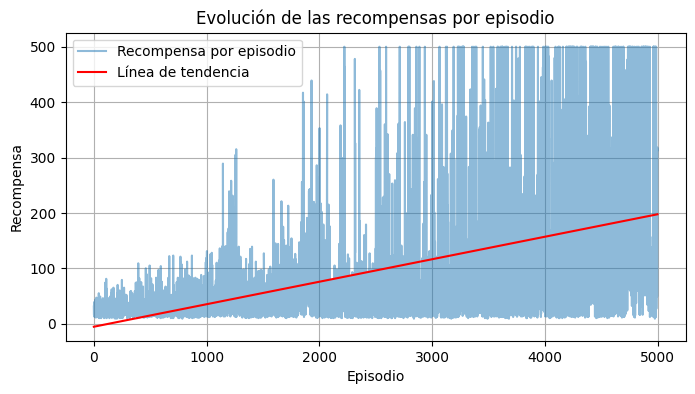

In [20]:
plot(rewards_per_episode_dqn)

## Análisis de Resultados: Longitud de Episodios

Esta gráfica muestra el número de pasos de cada episodio, que en CartPole-v1 **coincide directamente con la recompensa** (cada paso otorga +1).

### Observaciones:
- **Primeros ~2000 episodios**: Las longitudes rondan los 9–100 pasos (media de ~27 en los primeros 500), con picos esporádicos de mayor duración a medida que avanza el entrenamiento.
- **A partir del episodio ~2200**: Aumento sostenido de episodios que alcanzan 400–500 pasos, coincidiendo con la reducción progresiva de $\varepsilon$.
- **Fase final (4000–5000)**: Grupo más denso de episodios con longitudes altas (media ~194 en los últimos 1000 episodios, ~207 en los últimos 500). No se observa degradación; la tendencia sigue siendo creciente.

### ¿Por qué estos resultados?

**Las longitudes iniciales son cortas (9–100 pasos)** porque CartPole exige correcciones constantes del péndulo invertido. Con $\varepsilon > 0.5$, más de la mitad de las acciones son aleatorias, así que las correcciones llegan tarde o en la dirección incorrecta. Una política puramente aleatoria dura unos 20–25 pasos en CartPole, de modo que episodios de 50–100 pasos ya indican que la red empieza a representar algo útil.

**DQN no sufre la caída que se observa en SARSA** porque maneja la *deadly triad* (bootstrapping + aproximación funcional + política cambiante) de forma distinta:
   - SARSA es *on-policy*: actualiza $Q$ con la misma política que genera los datos. Cuando $\varepsilon$ decrece, la distribución de estados cambia de golpe y el modelo lineal (8 parámetros) no puede adaptarse sin divergir.
   - DQN es *off-policy*: aprende de un buffer con experiencias pasadas (distribución más estable) y usa una target network fija para los valores objetivo. Este desacoplamiento es precisamente lo que evita la divergencia.

**Los episodios cortos en la zona madura** (caídas a 20–100) se explican por el $\varepsilon$ residual ($\varepsilon \approx 0.082$ al final del entrenamiento) y por la sincronización de la target network cada 100 pasos, que puede cambiar bruscamente los valores objetivo y generar un período transitorio de inestabilidad.

**La arquitectura** (4→64→64→2) aporta ReLU en dos capas ocultas, lo que permite capturar interacciones no lineales entre las 4 variables de estado. La acción óptima depende de la combinación $(\theta, \dot{\theta}, x, \dot{x})$ en conjunto, algo que un modelo lineal no puede representar sin ingeniería de características explícita.

La tendencia creciente sostenida confirma que Experience Replay y Target Network cumplen su propósito: que las actualizaciones de $Q$ converjan hacia $Q^*$. Aunque DQN no tiene garantía formal de convergencia en general, los resultados muestran que los mecanismos de estabilización bastan para CartPole-v1.

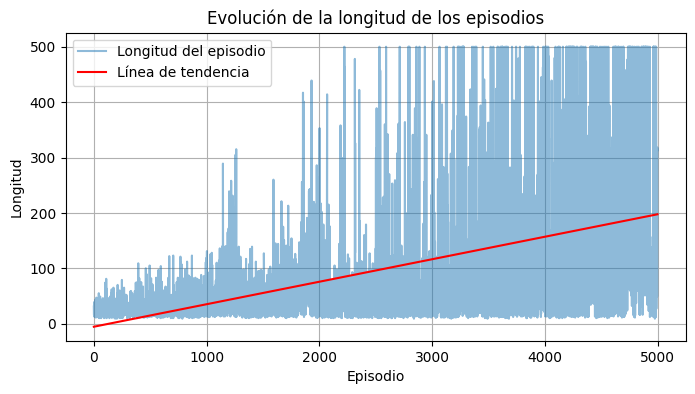

In [21]:
plot_episode_lengths(episodes_sizes_dqn)

## Evaluación de la Política Óptima

Se cargan los **mejores pesos** del modelo (correspondientes al episodio 2222, con recompensa de 500) y se evalúa la política greedy pura (sin exploración).

La función `optimal_policy_from_dqn` simula un episodio completo: para cada estado, la red predice $Q(s,a)$ para ambas acciones y se selecciona la de mayor valor. En esta evaluación, el agente mantiene el poste en equilibrio durante **133 pasos** con una distribución de acciones de 69 izquierda / 64 derecha.

### ¿Por qué no se alcanzan 500 pasos en evaluación?

Aunque el modelo alcanzó 500 pasos durante el entrenamiento (episodio 2222), la evaluación greedy pura obtiene 133 pasos. Esto se debe a que durante el entrenamiento el agente operaba con $\varepsilon \approx 0.33$ en ese episodio, de modo que cierta exploración aleatoria podía corregir situaciones en las que la política greedy toma decisiones subóptimas. Al eliminar toda exploración, la política determinista queda expuesta a las regiones del espacio de estados donde la aproximación de $Q$ no es suficientemente precisa. Además, los pesos guardados corresponden al episodio con mejor recompensa acumulada durante el entrenamiento con exploración, no necesariamente la mejor política greedy pura.

In [22]:
# Cargar los mejores pesos encontrados durante el entrenamiento
agent.model.load_state_dict(best_model_state)
print(f"Cargados los pesos del mejor episodio ({best_episode}) con recompensa: {best_reward}")

def optimal_policy_from_dqn(env, agent):
    """Evalúa la política óptima aprendida a partir de los valores de Q estimados por la red neuronal en DQN."""
    action_log = []
    frames = []

    state, _ = env.reset(seed=seed)
    done = False

    while not done:
        frames.append(env.render())
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        action = torch.argmax(agent.model(state_tensor)).item()
        action_log.append(action)
        state, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    return action_log, frames

def greedy_policy_dqn(state, agent):
    """Selecciona la acción óptima para DQN usando la red neuronal."""
    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
    return torch.argmax(agent.model(state_tensor)).item()

# Evaluar la política aprendida
env_eval = gym.make("CartPole-v1", render_mode="rgb_array")
action_log_dqn, frames_dqn = optimal_policy_from_dqn(env_eval, agent)

print(f"\nAcciones tomadas: {len(action_log_dqn)} pasos")
print(f"Distribución de acciones: Izquierda={action_log_dqn.count(0)}, Derecha={action_log_dqn.count(1)}")
env_eval.close()

Cargados los pesos del mejor episodio (2222) con recompensa: 500.0

Acciones tomadas: 133 pasos
Distribución de acciones: Izquierda=69, Derecha=64


## Grabación y Visualización del Vídeo

Se graba un vídeo del agente ejecutando la **política greedy** con los mejores pesos obtenidos durante el entrenamiento (episodio 2222).

En el vídeo se puede observar al carro intentando mantener el poste en equilibrio mediante correcciones alternadas izquierda/derecha. Aunque la política aprendida no consigue mantener el equilibrio durante los 500 pasos completos en modo greedy puro (alcanza 133 pasos), el comportamiento muestra que la red ha captado parcialmente la dinámica del sistema, realizando compensaciones coherentes hasta que acumula un error que lleva al poste fuera del rango de recuperación.

In [23]:
# Crear un nuevo entorno limpio para la grabación del vídeo
env_video = gym.make("CartPole-v1", render_mode="rgb_array")

# Grabar el video con la mejor política aprendida
video_dir = record_policy_with_fn_SarsaDQL(greedy_policy_dqn, agent, env_video, video_dir="videos_dqn_cartpole_best")

# Obtener el último video grabado
latest_video_file = get_latest_episode_video_file(video_dir)

# Mostrar información del video grabado
print("Video grabado:", latest_video_file)

# Mostrar el video en el notebook
embed_video(latest_video_file)

c:\Users\Rodrigo\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\Rodrigo\Desktop\repo_master\EML\EML-P1\EML_Entrega_1\eml_entornos_complejos\aproximados\videos_dqn_cartpole_best folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Video grabado: videos_dqn_cartpole_best\rl-video-episode-0.mp4


## Conclusiones

### Rendimiento del agente DQN en CartPole-v1

| Métrica | Valor |
|---|---|
| Mejor recompensa (entrenamiento) | **500** (máximo posible, episodio 2222) |
| Episodios con recompensa máxima | **220 / 5000** |
| Tendencia de aprendizaje | **Creciente** |
| Recompensa promedio global | **~96** |
| Evaluación greedy | **133 pasos** (69 izquierda / 64 derecha) |

El agente DQN consigue alcanzar la recompensa máxima de 500 pasos durante el entrenamiento en **220 episodios** (a partir del episodio 2222), gracias a la combinación de una red neuronal con capacidad suficiente (arquitectura 4→64→64→2, ~4290 parámetros) y los mecanismos de estabilización propios de DQN.

**Experience Replay** (buffer de 10000 transiciones) almacena experiencias pasadas y las muestrea de forma aleatoria para entrenar, lo que rompe la correlación temporal entre muestras, reutiliza datos y suaviza la distribución de entrenamiento. **Target Network** (sincronización cada 100 pasos) fija temporalmente los valores objetivo $y = r + \gamma \max_{a'} Q_{target}(s', a')$, convirtiendo un problema de regresión con target móvil en uno de supervisión semi-fija y evitando los ciclos de retroalimentación que causan divergencia.

La combinación de ambos mecanismos es lo que permite a DQN superar la *deadly triad* (bootstrapping + aproximación funcional + política no estacionaria) descrita por Sutton & Barto (2018, Cap. 11). SARSA Semi-Gradiente, que carece de estos mecanismos, no puede evitar la divergencia con un modelo lineal de solo 8 parámetros.

### Brecha entrenamiento–evaluación

Un resultado notable es la **brecha entre el rendimiento en entrenamiento (500 pasos) y en evaluación greedy (133 pasos)**. Esto se explica por varios factores:
- El modelo que alcanzó 500 pasos lo hizo con $\varepsilon \approx 0.33$, lo que significa que un tercio de las acciones eran aleatorias. Paradójicamente, esa exploración residual puede haber corregido decisiones subóptimas de la red en estados críticos.
- La evaluación greedy pura es determinista y amplifica cualquier imprecisión en la función $Q$ aprendida: basta un error sistemático en una región del espacio de estados para que el poste caiga.
- Con solo 5000 episodios y $\varepsilon_{decay} = 0.9995$, el epsilon final es $\approx 0.082$ (no llega al mínimo configurado de 0.01), lo que indica que el entrenamiento aún no ha alcanzado la fase de explotación profunda.

Para cerrar esta brecha se podrían explorar estrategias como: más episodios de entrenamiento, un decaimiento de epsilon más agresivo, o técnicas como Double DQN o Dueling DQN.

### Comparación con SARSA Semi-Gradiente

| Aspecto | SARSA Semi-Gradiente | DQN |
|---|---|---|
| Modelo | Lineal (8 params) | Red neuronal (4290 params) |
| Política | On-policy | Off-policy |
| Estabilización | Ninguna | Experience Replay + Target Net |
| Mejor recompensa | 298 / 500 (59.6%) | **500 / 500 (100%)** |
| Tendencia | Decreciente | **Creciente** |
| Evaluación greedy | 298 pasos | 133 pasos |
| Deadly triad | Sin mitigación | Mitigada |

Aunque DQN supera a SARSA en recompensa máxima de entrenamiento (500 vs. 298) y en tendencia (creciente vs. decreciente), SARSA obtiene mejor resultado en la evaluación greedy (298 vs. 133 pasos). Esto sugiere que el modelo lineal de SARSA, aunque limitado, generaliza de forma más directa su política aprendida al modo greedy, mientras que DQN, con mayor capacidad expresiva, puede sobreajustarse a las trayectorias vistas durante el entrenamiento con exploración.

Este experimento muestra de forma práctica que los avances de Mnih et al. (2015) son condiciones necesarias para que el aprendizaje profundo por refuerzo funcione en entornos con estados continuos. Sin embargo, también evidencia que alcanzar buenas recompensas durante el entrenamiento no garantiza automáticamente una política greedy robusta, y que el ajuste fino de hiperparámetros (especialmente el schedule de $\varepsilon$) es crucial para el rendimiento final.